In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from scipy.optimize import curve_fit

import os
import sys
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))
from plot_phases import plot_phase_line, plot_phase_derivatives, plot_power_law

In [ ]:
# === Configuration ===
data_root = Path("N4096/flex0p5")  # adjust to where your results live
output_root = Path("N4096/combined_results")
output_root.mkdir(exist_ok=True, parents=True)

# Known parameter arrays
FLEX_STRENGTH_values = [0.500]

start = 0.005
end = 0.35
# n = 401
# step = (end - start) / (n - 1)
step = 0.00075
n = int((end - start) / step + 1)
S_values = [round(start + i * step, 5) for i in range(n)]

# --- Helpers ---

def fmt_folder_val(x: float) -> str:
    """
    Format a float for folder name like:
    0.05 -> flex005, 0.1 -> flex01, 0.995 -> flex0995
    """
    if x == 1.0:
        return "10"
    return str(x).replace('.', '')

def fmt_val(x: float) -> str:
    """Format float for filename (S and F inside .npz)"""
    if x == 1.0:
        return "1"
    s = f"{x:.5f}".rstrip('0').rstrip('p')
    return s.replace('.', 'p')

def combine_arrays(arrs, stds, n=20):
    """Combine replicate means and stds across replicates."""
    arrs = np.stack(arrs)
    stds = np.stack(stds)
    K = arrs.shape[0]
    means = arrs.mean(axis=0)

    SS_within = ((n - 1) * stds**2).sum(axis=0)
    SS_between = (n * (arrs - means)**2).sum(axis=0)

    pooled_var = (SS_within + SS_between) / (K * n - 1)
    pooled_std = np.sqrt(pooled_var)
    return means, pooled_std


# --- Combination loop ---

summary_rows = []
total_tasks = len(FLEX_STRENGTH_values) * len(S_values)

with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
    for F in FLEX_STRENGTH_values:
        f_dir = data_root
        if not f_dir.exists():
            tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={F} ({f_dir})")
            pbar.update(len(S_values))
            continue

        for S in S_values:
            pattern = f"*S{fmt_val(S)}_flex{fmt_val(F)}_*.npz"
            files = list(f_dir.glob(pattern))
            pbar.update(1)

            if not files:
                tqdm.write(f"⚠️  No files for S={S}, F={F}: {pattern}")
                continue

            data = [np.load(f) for f in files]
            keys = ["T0", "T1", "T2", "T3", "CD"]
            combined = {}

            for k in keys:
                means = [d[k] for d in data]
                stds = [d[f"{k}_std"] for d in data]
                m, s = combine_arrays(means, stds)
                combined[k] = m
                combined[f"{k}_std"] = s

            # Save combined time-series .npz
            out_npz = output_root / f"COMBINED_S{fmt_val(S)}_F{fmt_val(F)}.npz"
            np.savez_compressed(out_npz, **combined, S=S, F=F)

            # Store final-timestep summary
            final = {k: combined[k][-1] for k in keys}
            final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
            summary_rows.append({"S": S, "F": F, **final, **final_std})

# === Write summary CSV ===
df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
df.to_csv("summary_s-phase_final_N4096.csv", index=False)

print(f"\n✅ Combined {len(summary_rows)} parameter groups")
print(f"📁 Results saved in: {output_root.resolve()}")

Combining simulations:   2%|▌                                       | 7/460 [00:01<01:56,  3.88it/s]

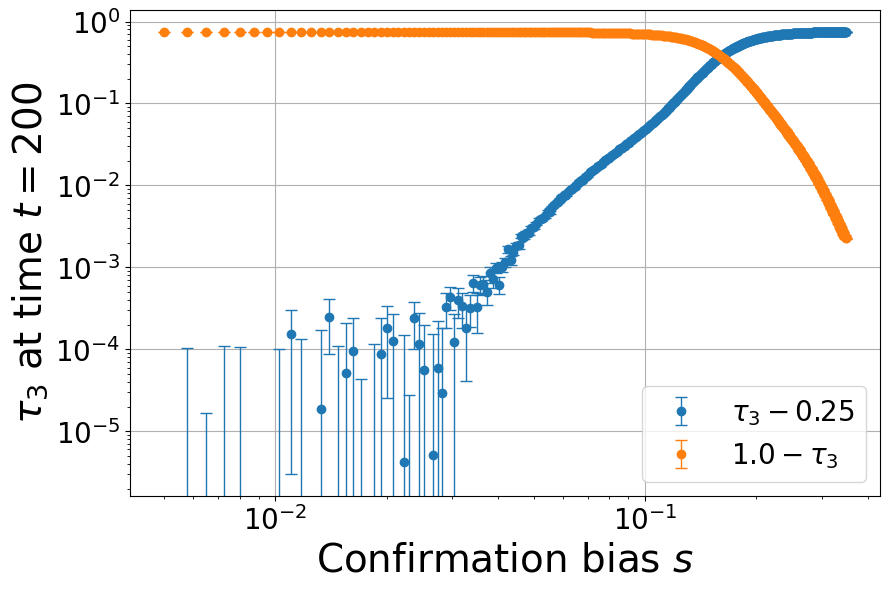

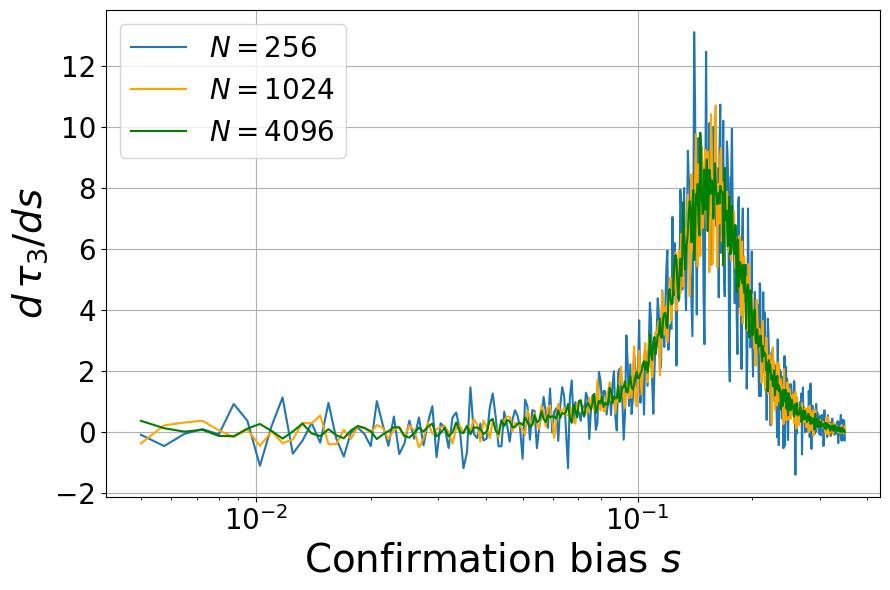

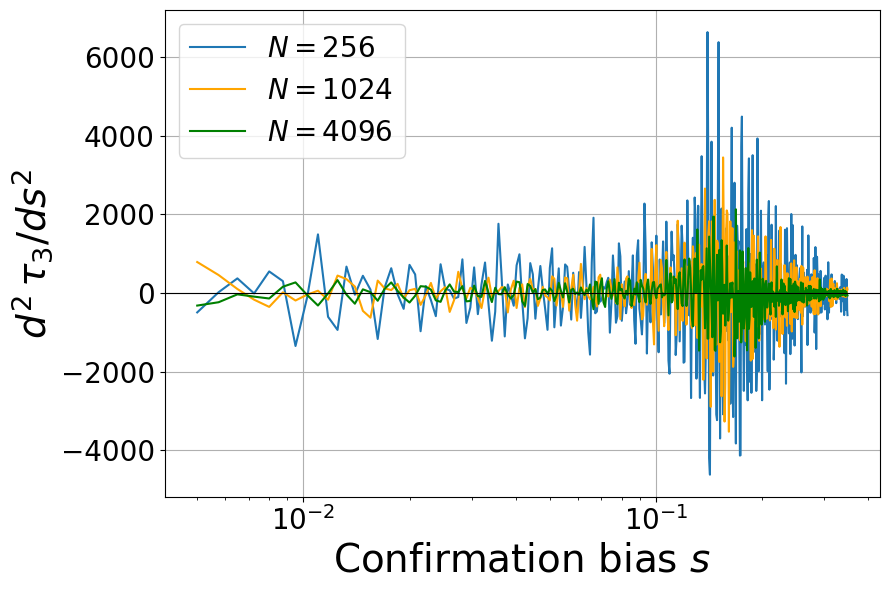

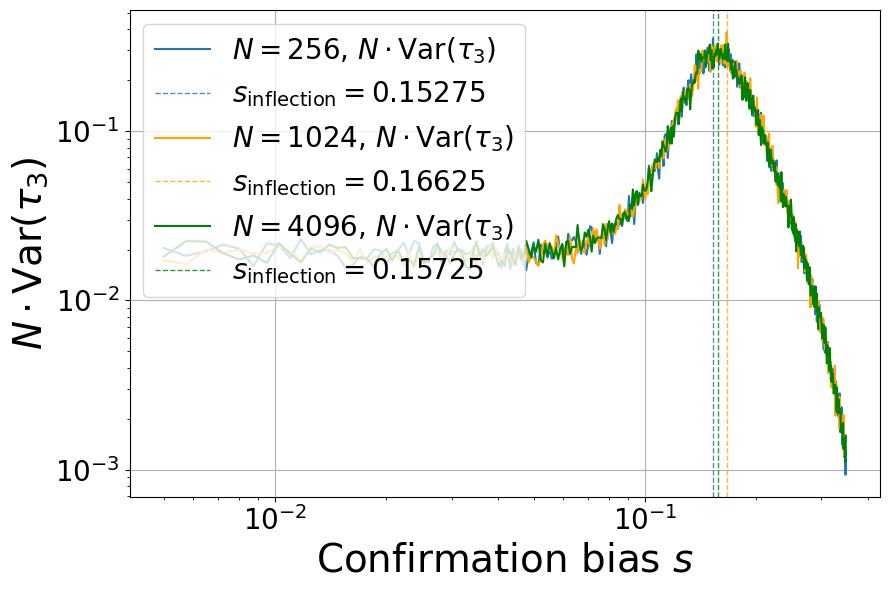

C:\Users\audso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\audso\GitHub\DHT-simulations-misinformation-propagation\plot_phases.py:522: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((0,6000))


Power-law R^2 (log-log) = 1.0000
Sigmoid R^2 = 0.9997


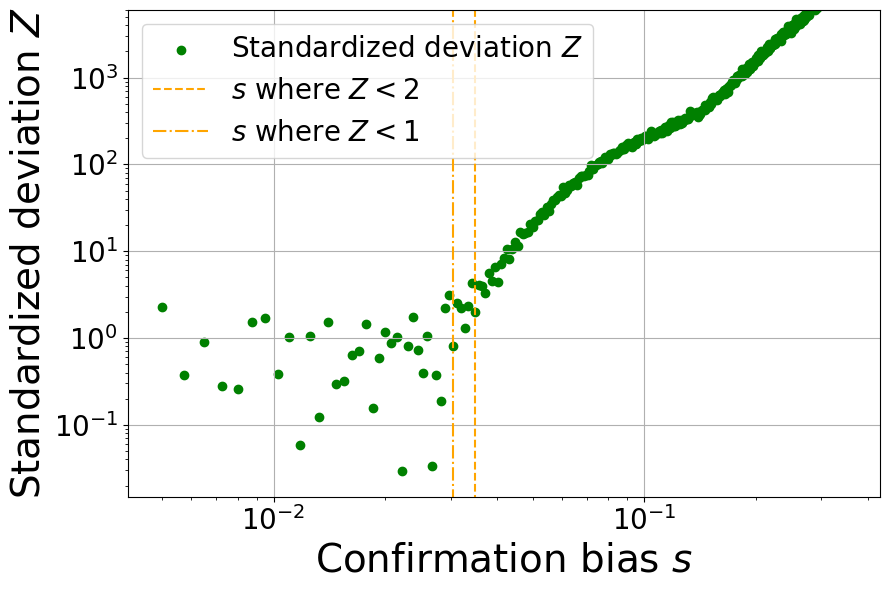

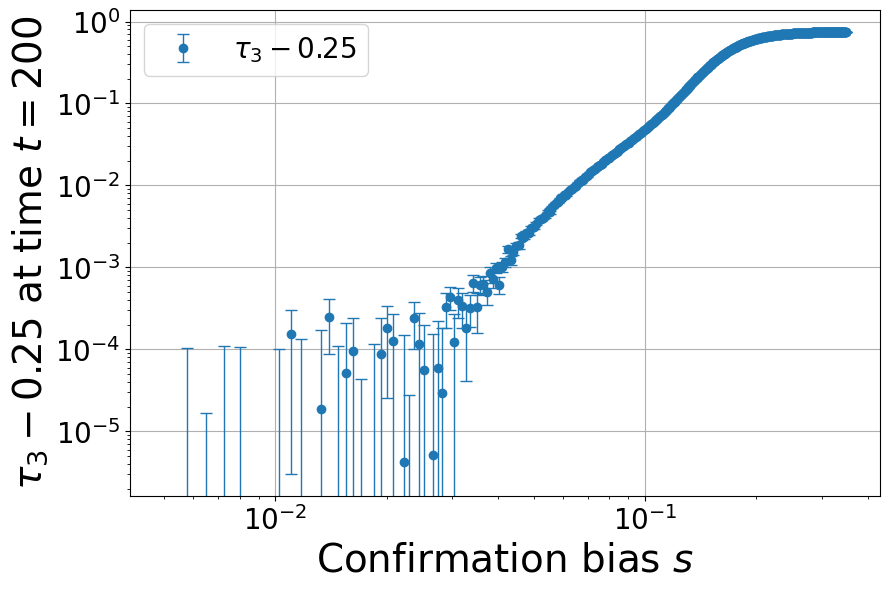

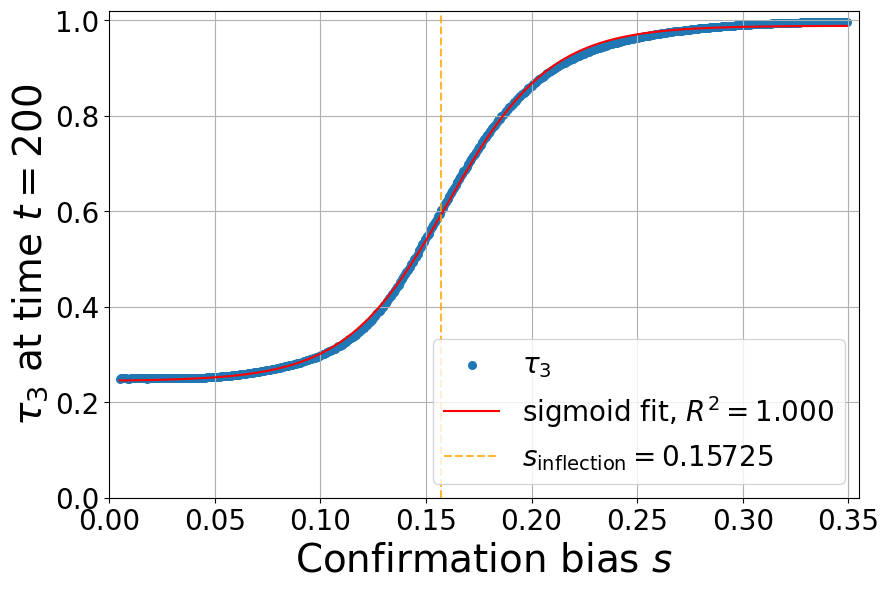

In [2]:
df4096 = pd.read_csv("summary_s-phase_final_N4096.csv")
df1024 = pd.read_csv("summary_s-phase_final_N1024.csv")
df256 = pd.read_csv("summary_s-phase_final_N256.csv")
dfs = [df256, df1024, df4096]
Ns = [256, 1024, 4096]

metrics = ["T0", "T1", "T2", "T3"]
metric="T3"
plot_phase_line(df4096, "S", metric, Path(f"phase_lines_{metric}_N4096.png"), Path("plots"), "log", "log", inverse=False)
plot_phase_derivatives(dfs, "S", metric, Ns, Path(f"phase_derivatives"), Path("plots"))
plot_power_law(df4096, "S", metric, Path(f"power_law_{metric}"), Path("plots"))

0.15725


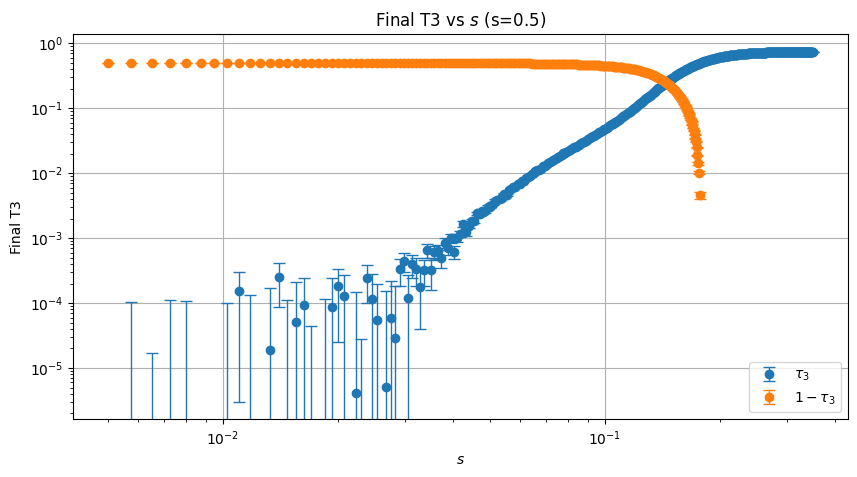

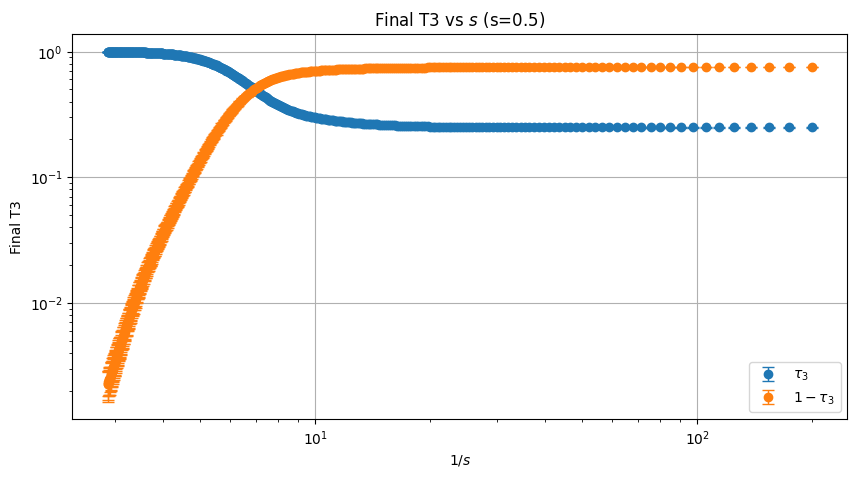

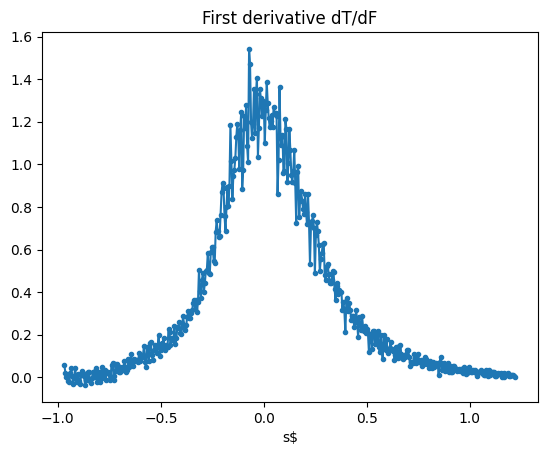

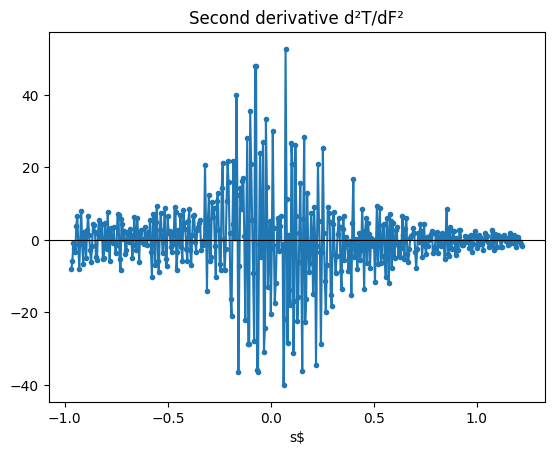

Critical S  = 0.160260
Sharpness a = 41.192654
Tlow        = 0.244410
Thigh       = 0.988984
R²          = 0.999660


C:\Users\audso\AppData\Local\Temp\ipykernel_38272\4099717473.py:104: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim((0, 0.355))


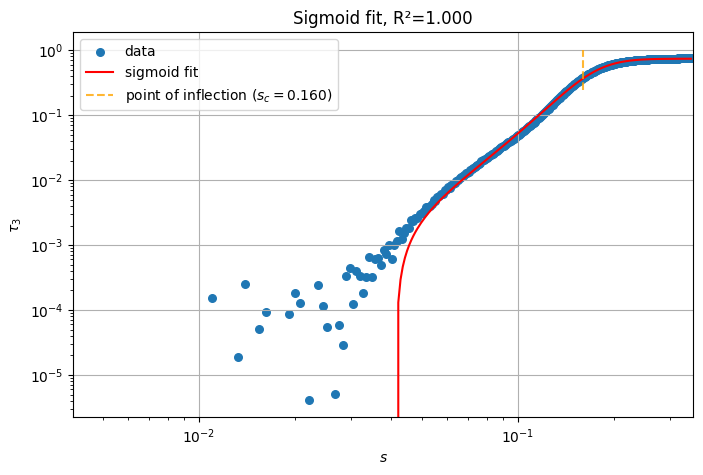

Critical exponent β = 0.12408516126910056


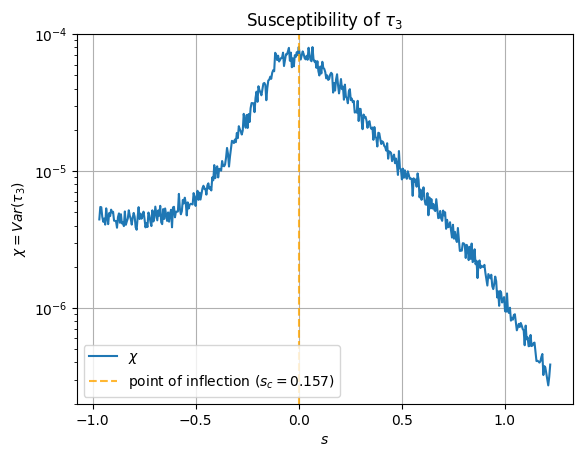

In [ ]:
# Load your final summary (update path if needed)
df = pd.read_csv("summary_s-phase_final_N4096.csv")
# df = pd.read_csv()

s_val = 0.5
df_flex = df[df['F'] == s_val].copy()

# Sort by S for a clean plot
df_flex = df_flex.sort_values("S")
S = df_flex["S"].values
Sc=S[np.argmax(df_flex["T3_std"]**2)]
# Sc=S[12]
print(Sc)

# Choose final truthfulness metric: T0, T1, T2, T3
metric = "T3"
std = metric + "_std"

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(df_flex["S"], df_flex[metric]-0.25, df_flex[std]/np.sqrt(200), fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(df_flex["S"], 0.75-df_flex[metric], df_flex[std]/np.sqrt(200), fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel(r"$s$")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.semilogx()
plt.ylabel(f"Final {metric}")
plt.title(fr"Final {metric} vs $s$ (s={s_val})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(1/df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(1/df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel(r"$1/s$")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.semilogx()
plt.ylabel(f"Final {metric}")
plt.title(fr"Final {metric} vs $s$ (s={s_val})")
plt.grid(True)
plt.legend()
plt.show()

s_all = (df_flex["S"].values - Sc) / Sc
dT3 = np.gradient(df_flex[metric], s_all)
d2T3 = np.gradient(dT3, s_all)
plt.figure()
plt.plot(s_all, dT3, '.-')
plt.title("First derivative dT/dF")
plt.xlabel(r"s$")
plt.show()

plt.figure()
plt.plot(s_all, d2T3, '.-')
plt.axhline(0, color='k', linewidth=0.8)
plt.title("Second derivative d²T/dF²")
plt.xlabel(r"s$")
plt.show()

def sigmoid(S, a, Sc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(S - Sc)))

S = df_flex["S"].values
T = df_flex[metric].values

p0 = [50, 0.3, min(T), max(T)]

# Fit
params, cov = curve_fit(sigmoid, S, T, p0=p0, maxfev=50000)
a, Sc, Tlow, Thigh = params

# Predictions
T_pred = sigmoid(S, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical S  = {Sc:.6f}")
print(f"Sharpness a = {a:.6f}")
print(f"Tlow        = {Tlow:.6f}")
print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")

S_sorted = np.linspace(min(S), max(S), 500)
s = (S-Sc)/Sc
s_sorted = (S_sorted - Sc) / Sc
T_fit_curve = sigmoid(S_sorted, *params)

plt.figure(figsize=(8,5))
plt.scatter(S, T-0.25, label="data", s=30)
plt.plot(S_sorted, T_fit_curve-0.25, 'r-', label="sigmoid fit")
plt.vlines(Sc, ymin=0.24, ymax=1.02, color="orange", linestyles="dashed", alpha=0.8, label=fr"point of inflection ($s_c={Sc:.3f}$)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$s$")
plt.ylabel(r"$\tau_3$")
plt.title(f"Sigmoid fit, R²={R2:.3f}")
plt.legend()
# plt.ylim((0.24, 1.02))
plt.xlim((0, 0.355))
plt.grid()
plt.show()

Sc=df_flex["S"][np.argmax(df_flex["T3_std"]**2)]
mask = df_flex["S"] > Sc  # one side of transition
Sfit = df_flex["S"][mask]
Tfit = df_flex[metric][mask]
s = (Sfit - Sc) / Sc

logS = np.log(s)
logT = np.log(Tfit)
coef = np.polyfit(logS, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
# print("Critical exponent alpha =", 1/Sc)
s_all = (df_flex["S"].values - Sc) / Sc

plt.figure()
plt.plot(s_all, df_flex["T3_std"]**2, label=r"$\chi$")
# plt.xscale("log")
plt.vlines(s_all[np.argmax(df_flex["T3_std"]**2)], ymin=2e-7, ymax=1e-4, color="orange", linestyles="dashed", alpha=0.8, label=fr"point of inflection ($s_c = {S[np.argmax(df_flex['T3_std']**2)]:.3f}$)")
plt.ylabel(r"$\chi = Var(\tau_3)$")
plt.xlabel(r"$s$")
plt.yscale("log")
# plt.xlim((0, 0.355))
plt.ylim((2e-7, 1e-4))
plt.grid()
plt.legend()
plt.title(r"Susceptibility of $\tau_3$")
plt.show()

Tail exponent γ = 0.17013823999335626


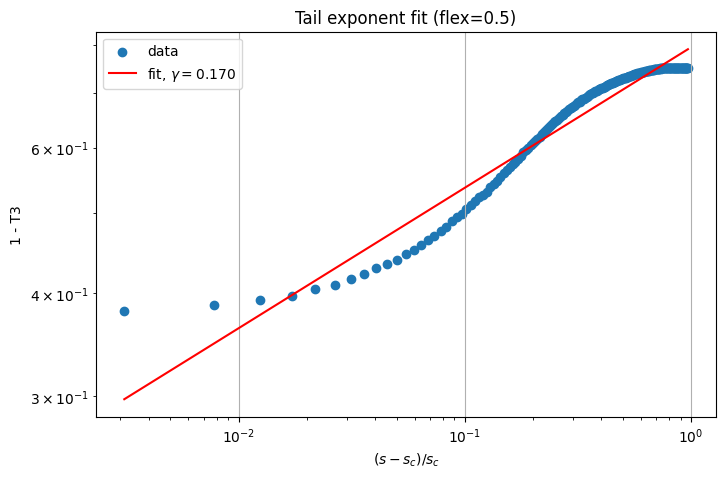

In [ ]:
Sc=0.16
tail = df[df["S"] < Sc]
mask = df_flex["S"] < Sc
Sfit = df_flex["S"][mask]
X = np.log(Sc - Sfit)
Y = np.log(df_flex["T3_std"][mask]**2)
gamma = - np.polyfit(X, Y, 1)[0]
S_tail = tail["S"].values
s_tail = (S_tail - Sc) / Sc
T3_tail = tail["T3"].values
one_minus_T3 = 1 - T3_tail

# --- log-log fit of tail ---
x = np.log(-s_tail)
y = np.log(one_minus_T3)

coef = np.polyfit(x, y, 1)
gamma = coef[0]
intercept = coef[1]

# --- predicted line ---
xfit = np.linspace(min(x), max(x), 200)
yfit = gamma * xfit + intercept

print("Tail exponent γ =", gamma)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.scatter(-s_tail, one_minus_T3, label="data")
plt.plot(np.exp(xfit), np.exp(yfit), 'r-', label=fr"fit, $\gamma =${gamma:.3f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$(s-s_c)/s_c$")
plt.ylabel("1 - T3")
plt.title("Tail exponent fit (flex=0.5)")
plt.grid(True)
plt.legend()
plt.show()

256 256
Critical exponent N4096 β = 0.12408516126910056
Critical exponent N1024 β = 0.09715694596207528
Critical exponent N256  β = 0.13975817910250793
Point of inflection N4096 s_c = 0.15725
Point of inflection N1024 s_c = 0.16625
Point of inflection N256 s_c = 0.15275


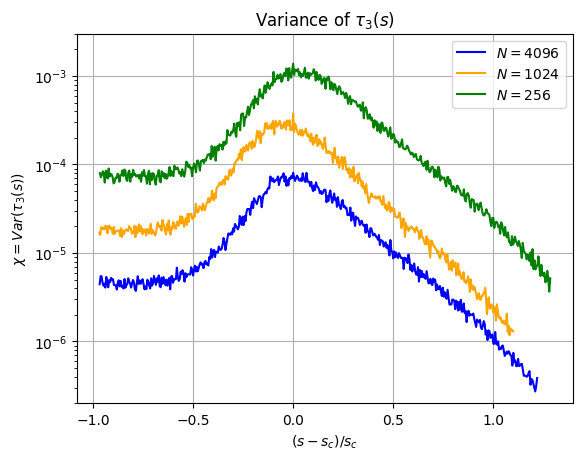

In [ ]:
df4096 = pd.read_csv("summary_s-phase_final_N4096.csv")
df1024 = pd.read_csv("summary_s-phase_final_N1024.csv")
df256 = pd.read_csv("summary_s-phase_final_N256.csv")

F_val = 0.5
df4096_flex = df4096[df4096['F'] == F_val].copy()
df1024_flex = df1024[df1024['F'] == F_val].copy()
df256_flex = df256[df256['F'] == F_val].copy()

# Sort by F for a clean plot
df4096_flex = df4096_flex.sort_values("S")
S4096 = df4096_flex["S"].values
Sc4096=S4096[np.argmax(df4096_flex["T3_std"]**2)]

df1024_flex = df1024_flex.sort_values("S")
S1024 = df1024_flex["S"].values
Sc1024=S1024[np.argmax(df1024_flex["T3_std"]**2)]

df256_flex = df256_flex.sort_values("S")
S256 = df256_flex["S"].values
Sc256=S256[np.argmax(df256_flex["T3_std"]**2)]

mask4096 = S4096 > Sc4096  # one side of transition
Sfit4096 = S4096[mask4096]
Tfit4096 = df4096_flex[metric][mask4096]
s4096 = (Sfit4096 - Sc4096) / Sc4096

mask1024 = S1024 > Sc1024  # one side of transition
Sfit1024 = S1024[mask1024]
Tfit1024 = df1024_flex[metric][mask1024]
s1024 = (Sfit1024 - Sc1024) / Sc1024

mask256 = S256 > Sc256  # one side of transition
Sfit256 = S256[mask256]
Tfit256 = df256_flex[metric][mask256]
s256 = (Sfit256 - Sc256) / Sc256

logS4096 = np.log(s4096)
logT4096 = np.log(Tfit4096)
print(len(logS4096), len(logT4096))
coef4096 = np.polyfit(logS4096, logT4096, 1)
beta4096 = coef4096[0]
logS1024 = np.log(s1024)
logT1024 = np.log(Tfit1024)
coef1024 = np.polyfit(logS1024, logT1024, 1)
beta1024 = coef1024[0]
logS256 = np.log(s256)
logT256 = np.log(Tfit256)
coef256 = np.polyfit(logS256, logT256, 1)
beta256 = coef256[0]

print("Critical exponent N4096 β =", beta4096)
print("Critical exponent N1024 β =", beta1024)
print("Critical exponent N256  β =", beta256)
print(fr"Point of inflection N4096 s_c = {Sc4096}")
print(fr"Point of inflection N1024 s_c = {Sc1024}")
print(fr"Point of inflection N256 s_c = {Sc256}")

s4096_all = (S4096 - Sc4096) / Sc4096
s1024_all = (S1024 - Sc1024) / Sc1024
s256_all = (S256 - Sc256) / Sc256

plt.figure()
plt.plot(s4096_all, df4096_flex["T3_std"]**2, label=r"$N=4096$", color="blue")
plt.plot(s1024_all, df1024_flex["T3_std"]**2, label=r"$N=1024$", color="orange")
plt.plot(s256_all, df256_flex["T3_std"]**2, label=r"$N=256$", color="green")
# plt.plot(S4096, df4096_flex["T3_std"]**2, label=r"$N=4096$", color="blue")
# plt.plot(S1024, df1024_flex["T3_std"]**2, label=r"$N=1024$", color="orange")
# plt.plot(S256, df256_flex["T3_std"]**2, label=r"$N=256$", color="green")
# plt.vlines(S4096[np.argmax(df4096_flex["T3_std"]**2)], ymin=2e-7, ymax=3e-3, color="blue", linestyles="dashed", alpha=0.5, label=fr"$N=4096$ $s_c = {S4096[np.argmax(df4096_flex['T3_std']**2)]}$")
# plt.vlines(S1024[np.argmax(df1024_flex["T3_std"]**2)], ymin=2e-7, ymax=3e-3, color="orange", linestyles="dashed", alpha=0.5, label=fr"$N=1024$ $s_c = {S1024[np.argmax(df1024_flex['T3_std']**2)]}$")
# plt.vlines(S256[np.argmax(df256_flex["T3_std"]**2)], ymin=2e-7, ymax=3e-3, color="green", linestyles="dashed", alpha=0.5, label=fr"$N=256$ $s_c = {S256[np.argmax(df256_flex['T3_std']**2)]}$")
plt.ylabel(r"$\chi = Var(\tau_3(s))$")
plt.xlabel(r"$(s-s_c)/s_c$")
plt.yscale("log")
# plt.xscale("log")
# plt.xlim((0, 0.355))
plt.ylim((2e-7, 3e-3))
plt.grid()
plt.legend()
plt.title(r"Variance of $\tau_3(s)$")
plt.show()

Critical S  = 0.160260
Sharpness a = 41.192654
Tlow        = 0.244410
Thigh       = 0.988984
R²          = 0.999660


C:\Users\audso\AppData\Local\Temp\ipykernel_10144\451697662.py:34: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(S_sorted, T_fit_curve, 'r-', label="sigmoid fit", linestyle="dashed")


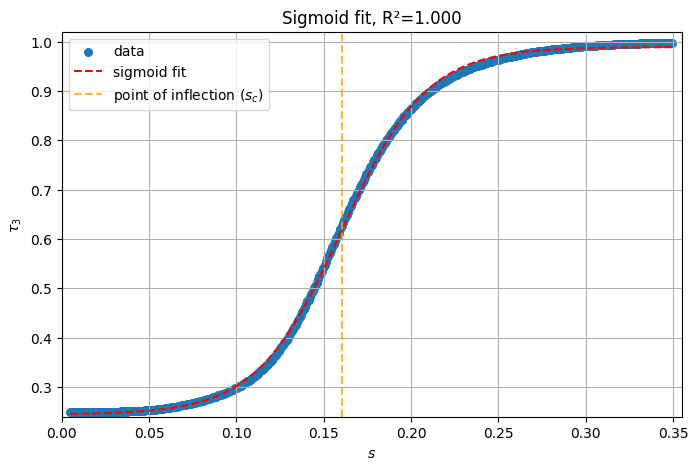

In [ ]:
def sigmoid(S, a, Sc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(S - Sc)))

S = df_flex["S"].values
T = df_flex[metric].values

p0 = [50, 0.3, min(T), max(T)]

# Fit
params, cov = curve_fit(sigmoid, S, T, p0=p0, maxfev=50000)
a, Sc, Tlow, Thigh = params

# Predictions
T_pred = sigmoid(S, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical S  = {Sc:.6f}")
print(f"Sharpness a = {a:.6f}")
print(f"Tlow        = {Tlow:.6f}")
print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")

S_sorted = np.linspace(min(S), max(S), 500)
s = (S-Sc)/Sc
s_sorted = (S_sorted - Sc) / Sc
T_fit_curve = sigmoid(S_sorted, *params)

plt.figure(figsize=(8,5))
plt.scatter(S, T, label="data", s=30)
plt.plot(S_sorted, T_fit_curve, 'r-', label="sigmoid fit", linestyle="dashed")
plt.vlines(Sc, ymin=0.24, ymax=1.02, color="orange", linestyles="dashed", alpha=0.8, label=r"point of inflection ($s_c$)")
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$s$")
plt.ylabel(r"$\tau_3$")
plt.title(f"Sigmoid fit, R²={R2:.3f}")
plt.legend()
plt.ylim((0.24, 1.02))
plt.xlim((0, 0.355))
plt.grid()
plt.show()

Critical exponent β = 0.11435800110512803
Critical exponent alpha = 6.250000000039063


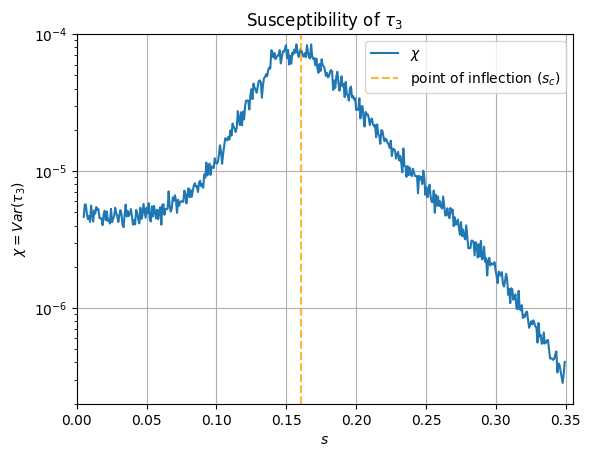

In [ ]:
mask = df_flex["S"] > Sc  # one side of transition
Sfit = df_flex["S"][mask]
Tfit = df_flex[metric][mask]
s = (Sfit - Sc) / Sc

logS = np.log(s)
logT = np.log(Tfit)

coef = np.polyfit(logS, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
print("Critical exponent alpha =", 1/0.159999999999)
s_all = (df_flex["S"].values - Sc) / Sc

plt.figure()
plt.plot(S, df_flex["T3_std"]**2, label=r"$\chi$")
# plt.xscale("log")
plt.vlines(Sc, ymin=2e-7, ymax=1e-4, color="orange", linestyles="dashed", alpha=0.8, label=r"point of inflection ($s_c$)")
plt.ylabel(r"$\chi = Var(\tau_3)$")
plt.xlabel(r"$s$")
plt.yscale("log")
plt.xlim((0, 0.355))
plt.ylim((2e-7, 1e-4))
plt.grid()
plt.legend()
plt.title(r"Susceptibility of $\tau_3$")
plt.show()

In [ ]:
# Load your final summary (update path if needed)
df = pd.read_csv("combined_results/summary_s-phase_final2.csv")

# Filter for flex = 0.5
flex_val = 0.5
df_flex = df[df['F'] == flex_val].copy()

# Sort by S for a clean plot
df_flex = df_flex.sort_values("S")

# Choose final truthfulness metric: T0, T1, T2, T3
metric = "T3"
std = metric + "_std"

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("S")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(1/df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(1/df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("1/S")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

dT3 = np.gradient(df_flex[metric], df_flex["S"])
print(fr"The peak of $\nabla\tau_3(S)$ is at S = {df_flex['S'][np.argmax(dT3)]}")
plt.plot(df_flex["S"], np.abs(dT3))
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xlabel("S")
plt.ylabel(fr"$\nabla\tau_3(S)$")
plt.show()

def sigmoid(S, a, Sc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(S - Sc)))

S = df_flex["S"].values
T = df_flex[metric].values

p0 = [50, 0.3, min(T), max(T)]

# Fit
params, cov = curve_fit(sigmoid, S, T, p0=p0, maxfev=50000)
a, Sc, Tlow, Thigh = params

# Predictions
T_pred = sigmoid(S, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical S  = {Sc:.6f}")
print(f"Sharpness a = {a:.6f}")
print(f"Tlow        = {Tlow:.6f}")
print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")

S_sorted = np.linspace(min(S), max(S), 500)
T_fit_curve = sigmoid(S_sorted, *params)

plt.figure(figsize=(8,5))
plt.scatter(S, T, label="data")
plt.plot(S_sorted, T_fit_curve, 'r-', label="sigmoid fit")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("S")
plt.ylabel("T3 final")
plt.title(f"Sigmoid fit (flex=0.5), R²={R2:.3f}")
plt.legend()
plt.grid(True)
plt.show()

mask = df_flex["S"] > Sc  # one side of transition
Sfit = df_flex["S"][mask]
Tfit = df_flex[metric][mask]

logS = np.log(Sfit - Sc)
logT = np.log(Tfit)

coef = np.polyfit(logS, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
print("Critical exponent alpha =", 1/0.159999999999)

plt.plot(df_flex["S"], df_flex["T3_std"]**2)
plt.xscale("log")
plt.yscale("log")
plt.title("Susceptibility χ = Var(T3)")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'combined_results/summary_s-phase_final2.csv'

C:\Users\audso\AppData\Local\Temp\ipykernel_23984\3381247423.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


<Figure size 1000x670 with 0 Axes>

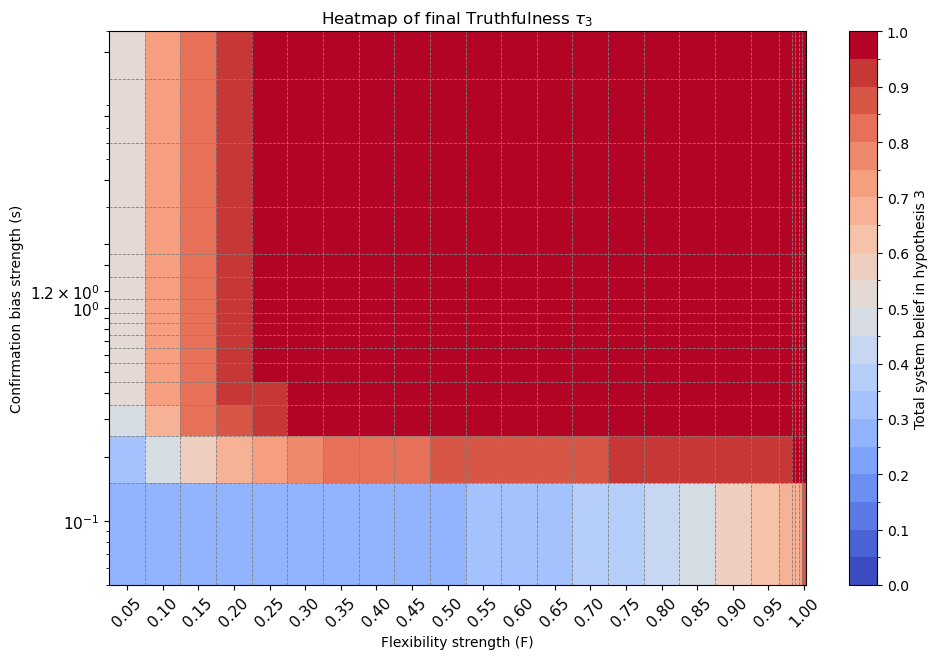

<Figure size 1000x670 with 0 Axes>

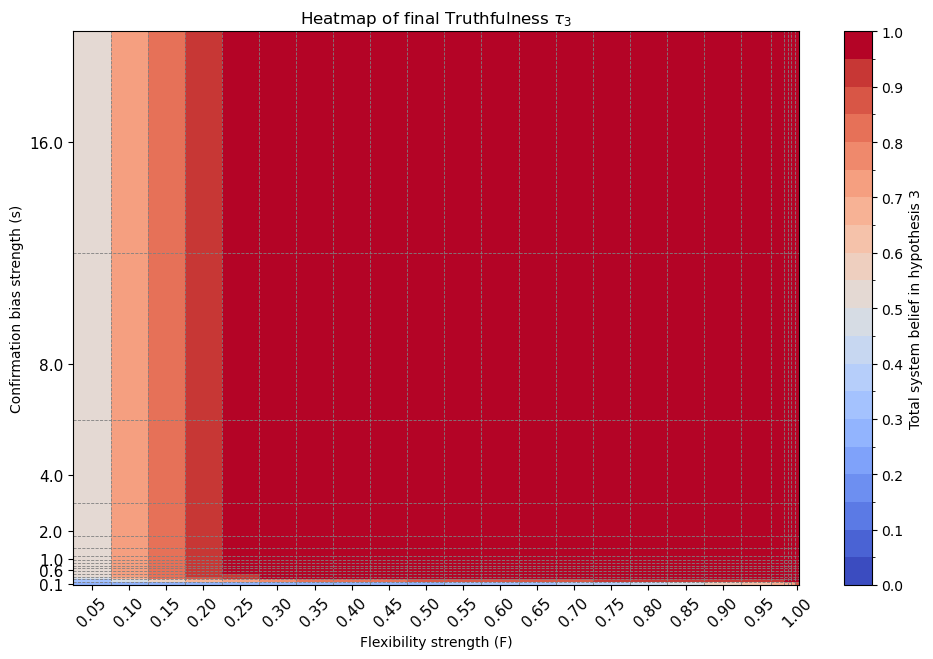

✅ Saved heatmap to plots\heatmap_T3.png


In [ ]:
data_path = Path("combined_results/summary_ba_final.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)
X, Y = np.meshgrid(FLEX_STRENGTH_values, S_values)

df = pd.read_csv(data_path)
metric = "T3" 
pivot = df.pivot(index="S", columns="F", values=metric)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

vmin, vmax = 0.0, 1.0
n_bins = 20
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

pivot = pivot.sort_index(axis=0, ascending=False).sort_index(axis=1)

def compute_edges(arr):
    arr = np.asarray(arr)
    edges = (arr[:-1] + arr[1:]) / 2
    edges = np.concatenate([[arr[0] - (edges[0] - arr[0])], edges, [arr[-1] + (arr[-1] - edges[-1])]])
    return edges
y_ticks = [0.1, 0.6, 1.0, 2, 4, 8, 16]

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")

ax.set_yscale('log')
plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap__logy_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")
plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
plt.yticks(y_ticks, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"✅ Saved heatmap to {out_path}")

Processing combined files: 100%|██████████| 384/384 [00:08<00:00, 47.18it/s]
C:\Users\audso\AppData\Local\Temp\ipykernel_33648\3342389618.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


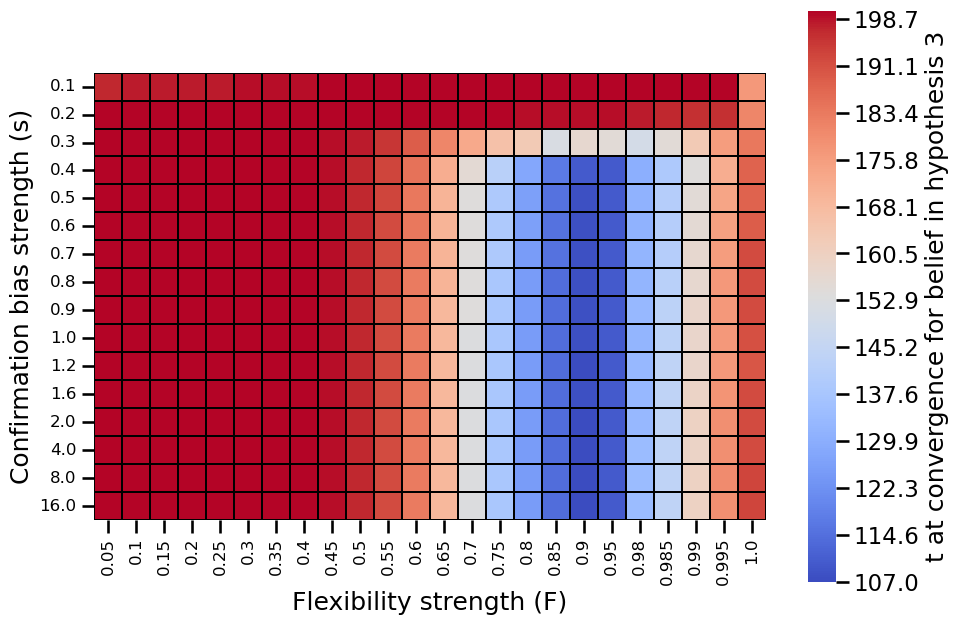

✅ Saved convergence heatmap to plots\convergence_heatmap_T3.png


In [ ]:
# === Configuration ===
data_root = Path("combined_results")
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

metric = "T3"          # change to T1, T2, T3, or CD as needed
threshold = 1e-4       # convergence criterion
n_bins = 10            # discrete color levels
vmin, vmax = 0, 200    # timestep range for color scale (adjust to your simulation length)

# === Load all combined files ===
files = list(data_root.glob("COMBINED_S*_F*.npz"))
rows = []

for f in tqdm(files, desc="Processing combined files"):
    data = np.load(f)
    S, F = data["S"].item(), data["F"].item()
    arr = data[metric]
    final_val = arr[-1]

    # find first timestep within threshold of final value
    diffs = np.abs(arr - final_val)
    conv_idx = np.argmax(diffs < threshold) if np.any(diffs < threshold) else len(arr) - 1
    rows.append({"S": S, "F": F, "converged_at": conv_idx})

# === Build DataFrame ===
df = pd.DataFrame(rows)
pivot = df.pivot(index="S", columns="F", values="converged_at")
pivot = pivot.sort_index(axis=0).sort_index(axis=1)

# === Fixed discrete colormap ===
vmin, vmax = 0.0, 200
n_bins = 200
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# === Plot ===
plt.figure(figsize=(10, 6.7))
sns.set_context("talk")

ax = sns.heatmap(
    pivot,
    cmap="coolwarm",
    vmin=np.min(df["converged_at"]),
    vmax=np.max(df["converged_at"]),
    # norm=norm,
    cbar_kws={
        "ticks": np.linspace(np.min(df["converged_at"]), 214, 15),
        "label": f"t at convergence for belief in hypothesis {metric[1]}",
    },
    linewidths=0.1,
    linecolor='black',
    square=True
)

# plt.title(f"Heatmap of {metric} (final timestep)")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
out_path = output_dir / f"convergence_heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()


print(f"✅ Saved convergence heatmap to {out_path}")
